# 01. EDA: Анализ и визуализация данных

## Импорт библиотек

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Загрузка данных

In [2]:
# Добавляем корневую папку проекта в sys.path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.data_loader import DataLoader

In [3]:
# Загружаем датасет
PROJECT_ROOT = project_root
DATASET_PATH = PROJECT_ROOT / "datasets" / "Credit Risk Data.csv"
KAGGLE_DS = "alexdister/credit-risk-dataset"

df = DataLoader.load(DATASET_PATH, KAGGLE_DS)

## Первичный осмотр структуры данных

In [4]:
print("Первые 5 строк:")
df.head()

Первые 5 строк:


,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,...,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
0,CUST_00001,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,...,43.6532,-79.3832,Self-employed,36,0.593220,8402.453850,0.735635,14,0.495557,0
1,CUST_00002,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,...,43.6532,-79.3832,Full-time,36,0.104167,1607.802794,0.271646,10,0.585436,3
2,CUST_00003,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,...,51.6214,-3.9436,Full-time,36,0.572917,2760.505633,0.860469,14,0.750732,0
3,CUST_00004,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,...,49.2827,-123.1207,Part-time,12,0.534351,7155.286150,0.643592,15,0.379333,0
4,CUST_00005,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,...,42.8864,-78.8784,Part-time,36,0.643382,15626.153440,0.930628,4,0.228103,0


In [5]:
print("Информация о датасете:")
df.info()

Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   client_ID                   32581 non-null  str    
 1   person_age                  32581 non-null  int64  
 2   person_income               32581 non-null  int64  
 3   person_home_ownership       32581 non-null  str    
 4   person_emp_length           31686 non-null  float64
 5   loan_intent                 32581 non-null  str    
 6   loan_grade                  32581 non-null  str    
 7   loan_amnt                   32581 non-null  int64  
 8   loan_int_rate               29465 non-null  float64
 9   loan_status                 32581 non-null  int64  
 10  loan_percent_income         32581 non-null  float64
 11  cb_person_default_on_file   32581 non-null  str    
 12  cb_person_cred_hist_length  32581 non-null  int64  
 13  gender             

In [6]:
print("Статистика по всем признакам:")
display(df.describe(include="all"))

Статистика по всем признакам:


,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,...,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
count,32581,32581.000000,3.258100e+04,32581,31686.000000,32581,32581,32581.000000,29465.000000,32581.000000,...,32581.000000,32581.000000,32581,32581.000000,32581.000000,3.258100e+04,32581.000000,32581.000000,32581.000000,32581.000000
unique,32581,NaN,NaN,4,NaN,6,7,NaN,NaN,NaN,...,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,CUST_00001,NaN,NaN,RENT,NaN,EDUCATION,A,NaN,NaN,NaN,...,NaN,NaN,Full-time,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,16446,NaN,6453,10777,NaN,NaN,NaN,...,NaN,NaN,19473,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,27.734600,6.607485e+04,NaN,4.789686,NaN,NaN,9589.371106,11.011695,0.218164,...,45.407613,-63.805473,NaN,38.501581,0.170553,1.156796e+04,0.345208,8.042018,0.499884,0.505141
std,NaN,6.348078,6.198312e+04,NaN,4.142630,NaN,NaN,6322.086646,3.240459,0.413006,...,7.644809,46.615580,NaN,16.012441,0.107049,1.306093e+04,0.129406,4.328087,0.259530,0.711745
min,NaN,20.000000,4.000000e+03,NaN,0.000000,NaN,NaN,500.000000,5.420000,0.000000,...,29.760400,-123.365600,NaN,12.000000,0.000789,2.252074e+02,0.064502,0.000000,0.050001,0.000000
25%,NaN,23.000000,3.850000e+04,NaN,2.000000,NaN,NaN,5000.000000,7.900000,0.000000,...,40.712800,-96.797000,NaN,24.000000,0.089655,5.387168e+03,0.251236,4.000000,0.275358,0.000000
50%,NaN,26.000000,5.500000e+04,NaN,4.000000,NaN,NaN,8000.000000,10.990000,0.000000,...,46.813900,-75.697200,NaN,36.000000,0.148148,8.995071e+03,0.333188,8.000000,0.500289,0.000000
75%,NaN,30.000000,7.920000e+04,NaN,7.000000,NaN,NaN,12200.000000,13.470000,0.000000,...,51.507400,-3.943600,NaN,60.000000,0.229167,1.456293e+04,0.423142,12.000000,0.725056,1.000000


Типы данных колонок:


str        12
float64     9
int64       8
Name: count, dtype: int64

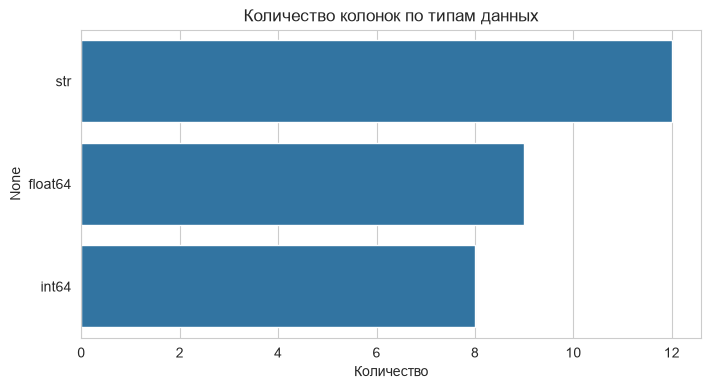

In [7]:
# Распределение типов колонок
dtype_counts = df.dtypes.value_counts()
print("Типы данных колонок:")
display(dtype_counts)

# Визуализация
sns.set_style("whitegrid")
plt.figure(figsize=(8, 4))
sns.barplot(x=dtype_counts.values, y=dtype_counts.index.astype(str))
plt.title("Количество колонок по типам данных")
plt.xlabel("Количество")
plt.show()

In [8]:
# Категориальные признаки
cat_cols = df.select_dtypes(include=["str"]).columns.tolist()
if cat_cols:
    print(f"Категориальные колонки ({len(cat_cols)}):")
    for col in cat_cols:
        uniq = df[col].nunique()
        print(f"  {col}: {uniq} уникальных значений")
        if uniq <= 100:
            print(f"    Примеры: {df[col].unique().tolist()}")
else:
    print("Категориальных колонок не найдено.")

Категориальные колонки (12):
  client_ID: 32581 уникальных значений
  person_home_ownership: 4 уникальных значений
    Примеры: ['RENT', 'OWN', 'MORTGAGE', 'OTHER']
  loan_intent: 6 уникальных значений
    Примеры: ['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION']
  loan_grade: 7 уникальных значений
    Примеры: ['D', 'B', 'C', 'A', 'E', 'F', 'G']
  cb_person_default_on_file: 2 уникальных значений
    Примеры: ['Y', 'N']
  gender: 2 уникальных значений
    Примеры: ['Male', 'Female']
  marital_status: 4 уникальных значений
    Примеры: ['Married', 'Divorced', 'Single', 'Widowed']
  education_level: 4 уникальных значений
    Примеры: ['High School', 'Master', 'Bachelor', 'PhD']
  country: 3 уникальных значений
    Примеры: ['Canada', 'UK', 'USA']
  state: 9 уникальных значений
    Примеры: ['Ontario', 'Wales', 'BC', 'New York', 'California', 'Quebec', 'Texas', 'Scotland', 'England']
  city: 18 уникальных значений
    Примеры: ['Toronto', 'Swansea', 

In [9]:
# Числовые признаки, которые ведут себя как категориальные
CATEGORICAL_THRESHOLD = 100

num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
potential_cat = []
for col in num_cols:
    n_unique = df[col].nunique()
    if n_unique <= CATEGORICAL_THRESHOLD:
        potential_cat.append((col, n_unique))

print(f"Числовые признаки с <= {CATEGORICAL_THRESHOLD} уникальными значениями (потенциально категориальные):")
for col, n in potential_cat:
    print(f"  {col}: {n} уникальных")

Числовые признаки с <= 100 уникальными значениями (потенциально категориальные):
  person_age: 58 уникальных
  person_emp_length: 36 уникальных
  loan_status: 2 уникальных
  loan_percent_income: 77 уникальных
  cb_person_cred_hist_length: 29 уникальных
  city_latitude: 18 уникальных
  city_longitude: 18 уникальных
  loan_term_months: 4 уникальных
  open_accounts: 16 уникальных
  past_delinquencies: 7 уникальных


In [10]:
# Полная информация по уникальным значениям
unique_info = pd.DataFrame({
    "Тип": df.dtypes,
    "Уникальных": df.nunique(),
    "Доля уникальных (%)": (df.nunique() / len(df) * 100).round(2)
})
unique_info.sort_values("Уникальных", ascending=True, inplace=True)
print("Количество уникальных значений по всем колонкам\n")
display(unique_info)

Количество уникальных значений по всем колонкам



,Тип,Уникальных,Доля уникальных (%)
cb_person_default_on_file,str,2,0.01
gender,str,2,0.01
loan_status,int64,2,0.01
country,str,3,0.01
marital_status,str,4,0.01
education_level,str,4,0.01
employment_type,str,4,0.01
person_home_ownership,str,4,0.01
loan_term_months,int64,4,0.01
loan_intent,str,6,0.02


## Анализ пропусков

In [11]:
# Количество пропусков по каждому признаку
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Кол-во пропусков": missing,
    "Доля (%)": missing_pct
}).sort_values("Кол-во пропусков", ascending=False)
missing_df = missing_df[missing_df["Кол-во пропусков"] > 0]

print("Пропуски по колонкам:")
display(missing_df)

Пропуски по колонкам:


,Кол-во пропусков,Доля (%)
loan_int_rate,3116,9.563856
person_emp_length,895,2.747000


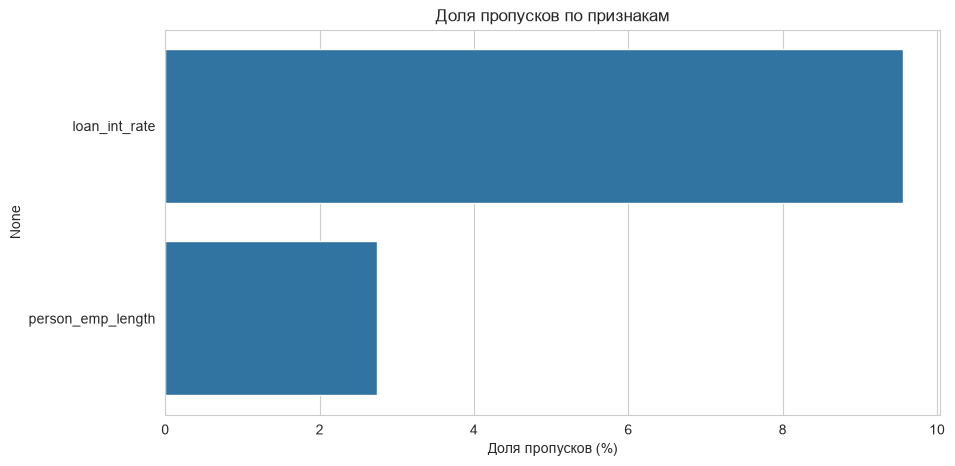

In [12]:
# Визуализация доли пропусков
missing_plot = missing_df.sort_values("Доля (%)", ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_plot["Доля (%)"], y=missing_plot.index)
plt.xlabel("Доля пропусков (%)")
plt.title("Доля пропусков по признакам")
plt.show()

In [13]:
# Анализ связи пропусков с целевой переменной
missing_cols = missing_df.index.tolist()

print("Влияние пропусков на целевую переменную\n")
for col in missing_cols:

    is_missing = df[col].isna()

    mean_with_missing = df.loc[is_missing, "loan_status"].mean()
    mean_without_missing = df.loc[~is_missing, "loan_status"].mean()

    print(f"Признак: {col}")
    print(f"  Доля дефолтов при наличии пропуска: {mean_with_missing:.4f} ({is_missing.sum()} записей)")
    print(f"  Доля дефолтов при отсутствии пропуска: {mean_without_missing:.4f} ({is_missing.sum()} записей)")
    print(f"  Разница: {mean_with_missing - mean_without_missing:.4f}\n")

Влияние пропусков на целевую переменную

Признак: loan_int_rate
  Доля дефолтов при наличии пропуска: 0.2067 (3116 записей)
  Доля дефолтов при отсутствии пропуска: 0.2194 (3116 записей)
  Разница: -0.0127

Признак: person_emp_length
  Доля дефолтов при наличии пропуска: 0.3151 (895 записей)
  Доля дефолтов при отсутствии пропуска: 0.2154 (895 записей)
  Разница: 0.0997



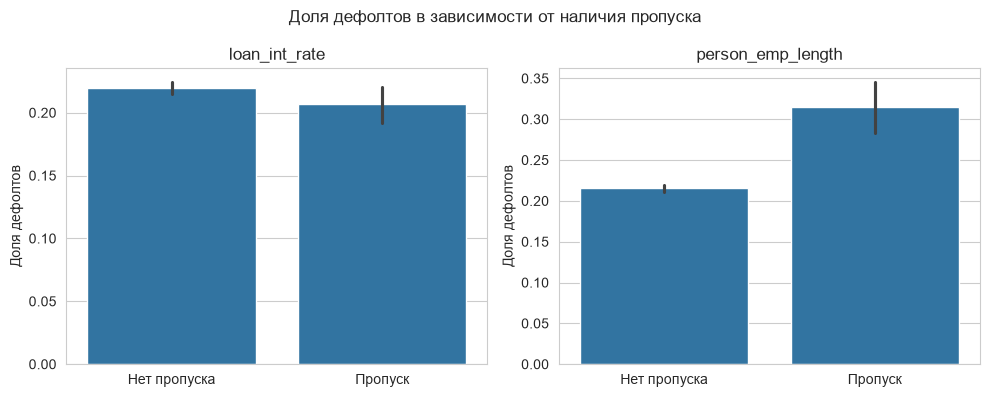

In [14]:
# Визуализация
fig, axes = plt.subplots(1, len(missing_cols), figsize=(10, 4))

for ax, col in zip(axes, missing_cols):
    is_missing = df[col].isnull()
    plot_data = pd.DataFrame({
        "Статус": ["Пропуск" if x else "Нет пропуска" for x in is_missing],
        "loan_status": df["loan_status"]
    })
    sns.barplot(data=plot_data, x="Статус", y="loan_status", ax=ax)
    ax.set_title(f'{col}')
    ax.set_ylabel("Доля дефолтов")
    ax.set_xlabel("")
plt.suptitle("Доля дефолтов в зависимости от наличия пропуска")
plt.tight_layout()
plt.show()

## Анализ дубликатов

In [15]:
# Полные дубликаты строк
print(f"Полных дубликатов строк: {df.duplicated().sum()}")

Полных дубликатов строк: 0


In [16]:
# Дубликаты по client_ID
print(f"Дубликатов по client_ID: {df.duplicated(subset="client_ID").sum()}")

Дубликатов по client_ID: 0
